c:\Users\nihal\Documents\Wong Quantum AI Lab\qml-amr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


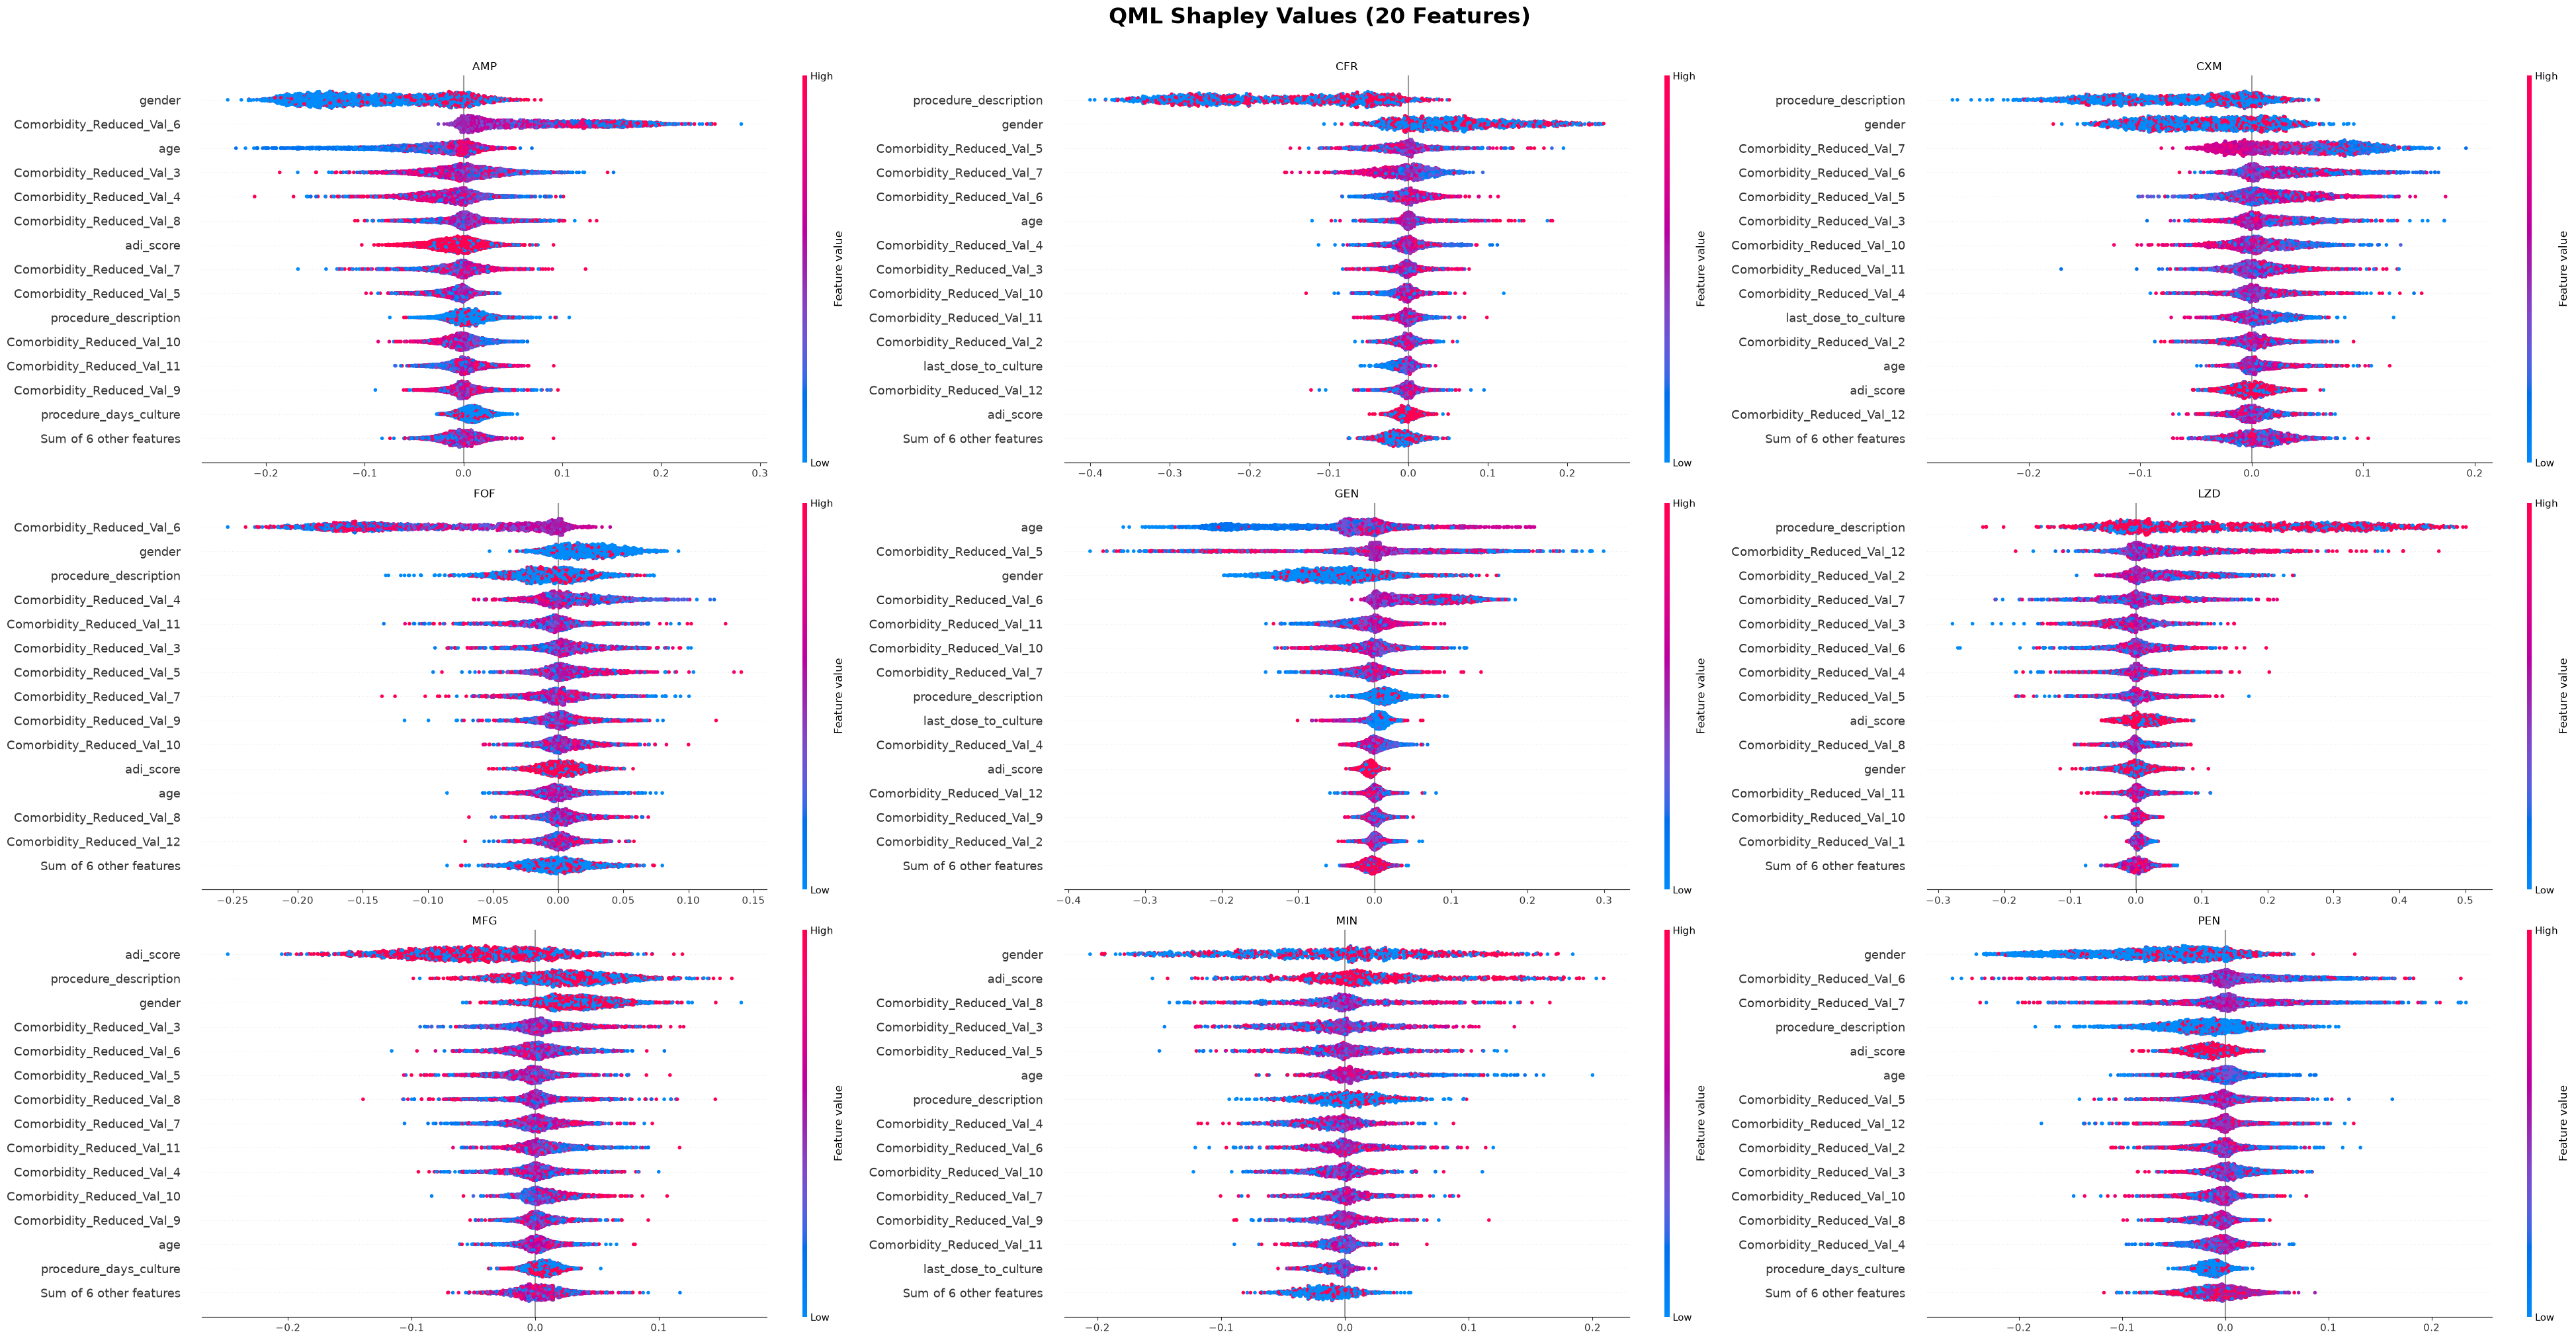

In [1]:
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt

drugs_list = ['AMP', 'CFR', 'CXM', 'FOF', 'GEN', 'LZD', 'MFG', 'MIN', 'PEN']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))
axes_flat = axes.flatten()
fig.suptitle("QML Shapley Values (20 Features)", fontsize=24, fontweight="bold", y=1.01)
for i in range(len(drugs_list)):
    DRUG = drugs_list[i]
    with open(f"QShapley/{DRUG}.sav", "rb") as file:
        shapley = pickle.load(file)
    if "_reduced" in DRUG or True:
        df = pd.read_csv(f"dataset/by_antibiotic_12comorbdims_dup/{DRUG}.csv")
        features = list(df.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant","Unnamed: 0"]).columns)
    else:
        df = pd.read_csv(f"dataset/by_antibiotic_dup/{DRUG}.csv")
        features = list(df.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant","Unnamed: 0",'Unnamed: 0.1']).columns)
    shapley.feature_names = features
    shap.plots.beeswarm(shapley[:,:,1], max_display=15, ax=axes_flat[i], show=False, plot_size=None)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_title(DRUG)


plt.tight_layout()
plt.show()